Starting Professional Sales Data Warehouse Project with Enhanced Visualizations...
Dataset generated: 15000 rows written to 'sales_data.csv'
ETL Starting - Raw data preview:
  transaction_id store_id region product_id                  product_name  \
0         T00001      S04  North       P017  Acer Predator Gaming Monitor   
1         T00002      S03   East       P006                 iPhone 14 Pro   
2         T00003      S05  South       P005          Keychron K8 Keyboard   
3         T00004      S05  South       P014       Jabra Elite 85t Earbuds   
4         T00005      S07  North       P001            Dell XPS 13 Laptop   

              category  quantity_sold  unit_price  total_sale        date  \
0          Electronics              5      599.99     2999.95  2025-03-13   
1          Electronics              9      999.99     8999.91  2024-10-23   
2          Accessories              6       89.99      539.94  2025-02-18   
3  Premium Accessories              5      229.99     1

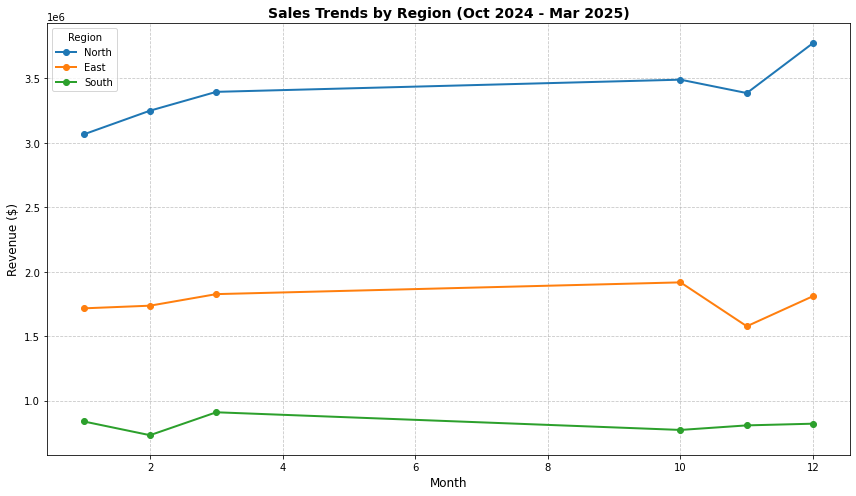

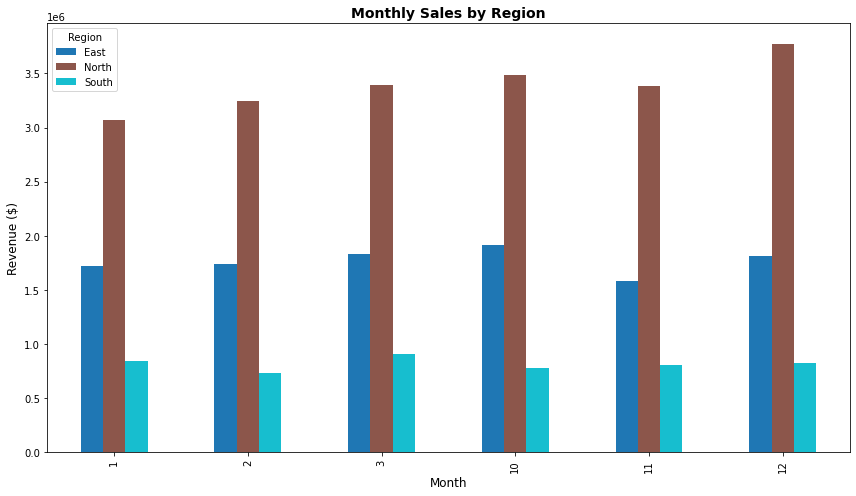

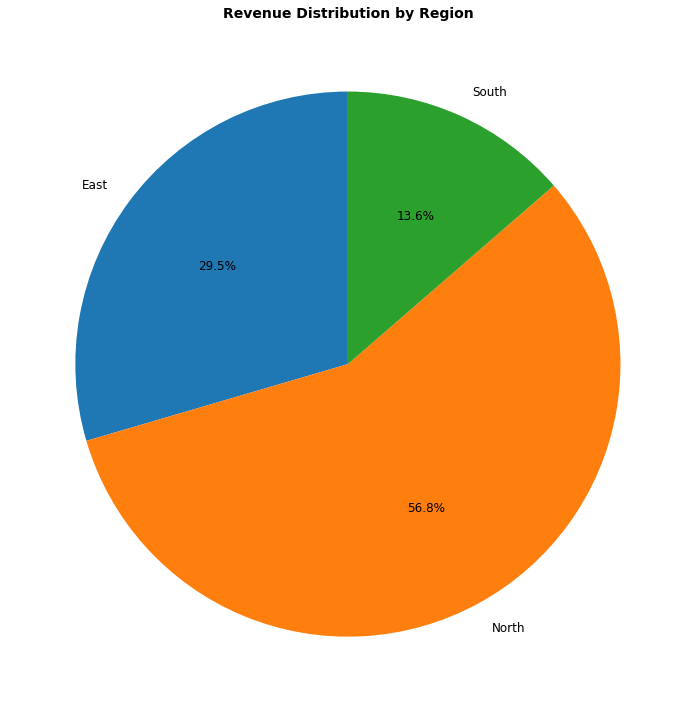


=== Inventory Levels by Region ===
region                  product_name  total_sold
  East             Anker 65W Charger        5495
  East         Samsung Galaxy Tab S8        4876
  East           Canon PIXMA Scanner        3296
  East                 iPhone 14 Pro        3165
  East          Apple Watch Series 8        3164
  East          Logitech C920 Webcam        1614
  East                iPad Pro 12.9"        1586
  East      Logitech MX Master Mouse        1540
 North  Acer Predator Gaming Monitor        4908
 North            Dell XPS 13 Laptop        4865
 North    Samsung 32" Curved Monitor        4832
 North SteelSeries Apex Pro Keyboard        3524
 North                iPad Pro 12.9"        3311
 North         Epson EcoTank Printer        3267
 North       HP LaserJet Pro Printer        3004
 North        Microsoft Surface Dock        1767
 North          Keychron K8 Keyboard        1743
 North                 iPhone 14 Pro        1629
 South  Bose QuietComfort Headpho

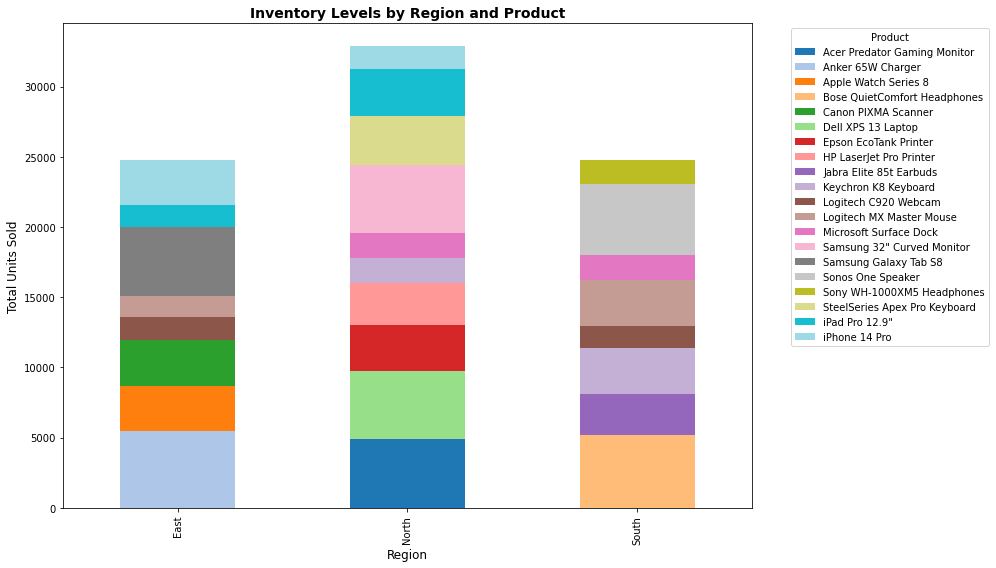

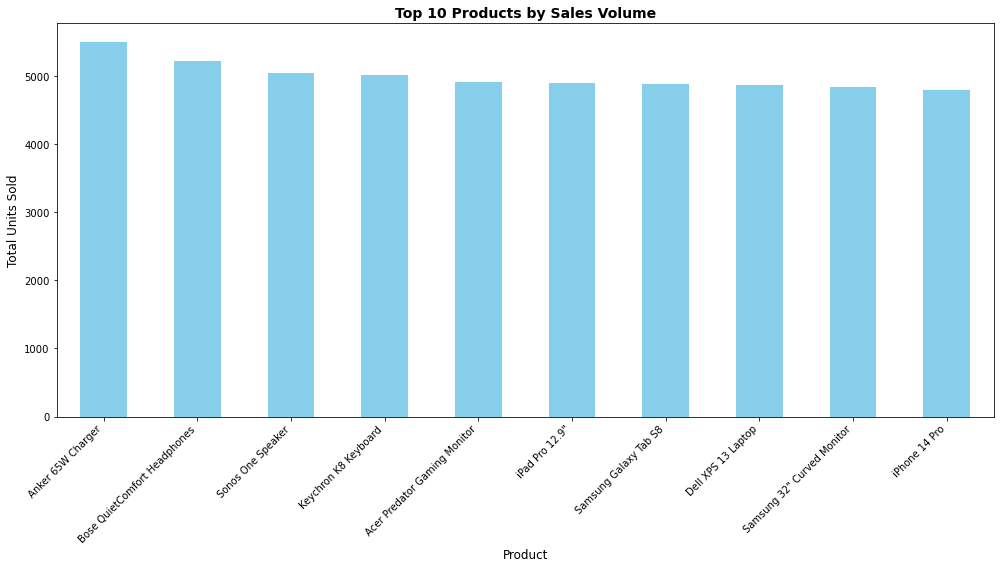

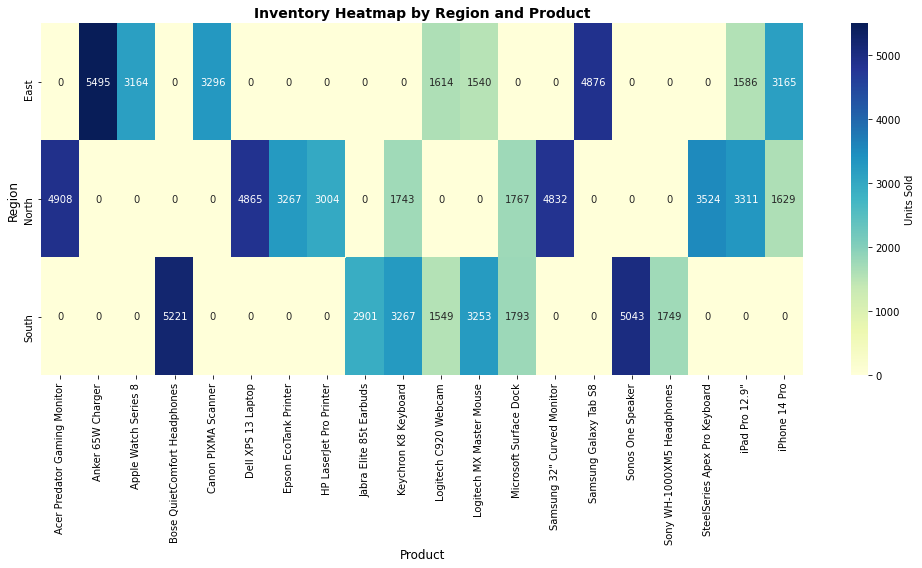


=== Customer Preferences by Store ===
store_id region                  product_name  total_sold
     S01  North  Acer Predator Gaming Monitor        1660
     S01  North                iPad Pro 12.9"        1634
     S01  North                 iPhone 14 Pro        1629
     S01  North    Samsung 32" Curved Monitor        1599
     S01  North            Dell XPS 13 Laptop        1560
     S02  South             Sonos One Speaker        1728
     S02  South  Bose QuietComfort Headphones        1682
     S02  South          Logitech C920 Webcam        1549
     S02  South      Logitech MX Master Mouse        1539
     S02  South          Keychron K8 Keyboard        1525
     S03   East             Anker 65W Charger        1884
     S03   East         Samsung Galaxy Tab S8        1738
     S03   East          Apple Watch Series 8        1691
     S03   East                 iPhone 14 Pro        1617
     S03   East                iPad Pro 12.9"        1586
     S04  North         Epson Eco

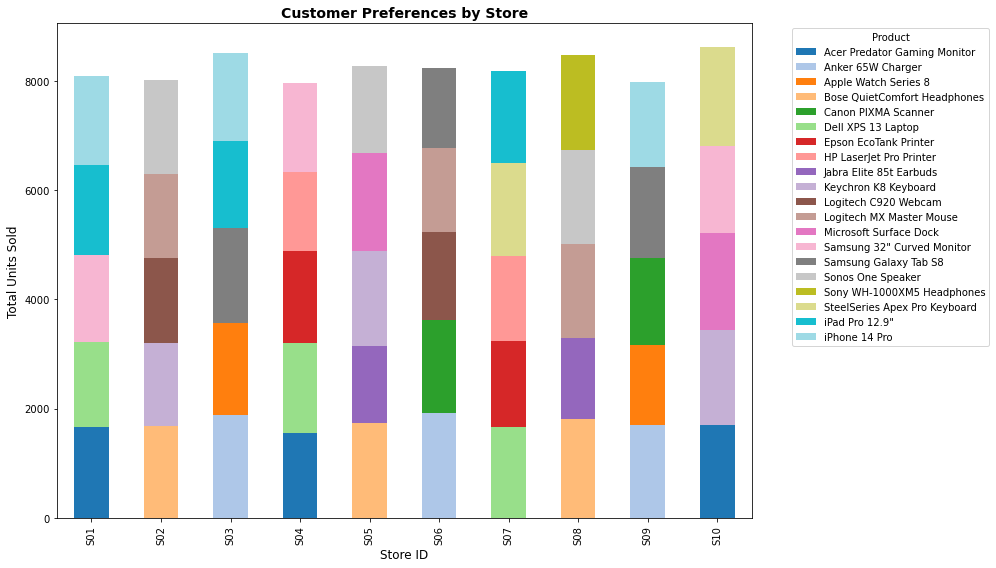

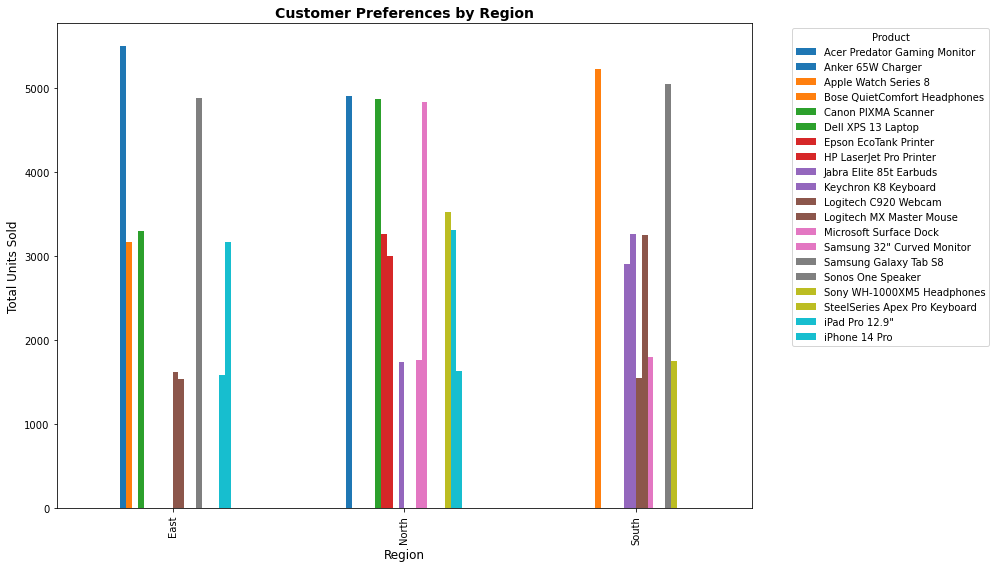

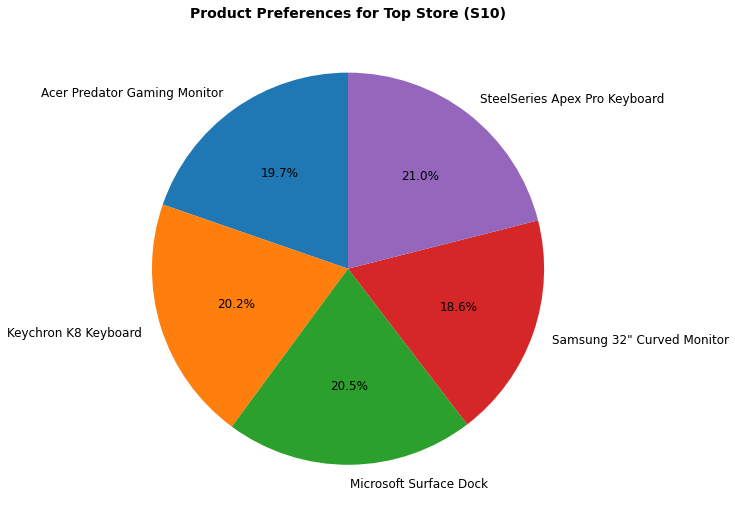


Project complete! Check outputs: sales_data.csv, database, reports, and visualizations.


In [1]:
#RICKY'S PROJECT
"""
Professional Sales Data Warehouse Project with Enhanced Visualizations
Author: Alimugonza richard
Date: March 25, 2025
Description: A data warehouse system that cosolidates sales data from multiple stores, regions, 
              and time periods.i generates the reports and insights about the sales trends, inventory levels, and custtomer preferences.
Dependencies: pandas, sqlalchemy, matplotlib, (optional: psycopg2 for PostgreSQL)
Outputs: sales_data.csv, database, report CSVs, PNG visualizations, log file
"""
#loading the packages that will be used in the project
import pandas as pd
from sqlalchemy import create_engine
import random
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import logging
import sys
import seaborn as sns 

# Configuration (# Default SQLite)
DB_CONNECTION_STRING = 'sqlite:///sales_warehouse.db'  
LOG_FILE = 'sales_warehouse.log'

# Setup logging
logging.basicConfig(filename=LOG_FILE, level=logging.INFO,
                    format='%(asctime)s - %(levelname)s - %(message)s')

# Step 1: Generating of our own Dataset
def generate_dataset(rows=15000, output_file='sales_data.csv'):
    try:
        logging.info("Starting dataset generation...")
        stores = {'S01': 'North', 'S02': 'South', 'S03': 'East', 'S04': 'North', 'S05': 'South',
                  'S06': 'East', 'S07': 'North', 'S08': 'South', 'S09': 'East', 'S10': 'North'}

        all_products = {
            'P001': ('Dell XPS 13 Laptop', 'Electronics', 1299.99),
            'P002': ('Bose QuietComfort Headphones', 'Premium Accessories', 299.99),
            'P003': ('Logitech MX Master Mouse', 'Accessories', 99.99),
            'P004': ('Samsung 32" Curved Monitor', 'Electronics', 399.99),
            'P005': ('Keychron K8 Keyboard', 'Accessories', 89.99),
            'P006': ('iPhone 14 Pro', 'Electronics', 999.99),
            'P007': ('iPad Pro 12.9"', 'Electronics', 1099.99),
            'P008': ('Sonos One Speaker', 'Premium Accessories', 199.99),
            'P009': ('Logitech C920 Webcam', 'Accessories', 79.99),
            'P010': ('Anker 65W Charger', 'Accessories', 39.99),
            'P011': ('HP LaserJet Pro Printer', 'Office Equipment', 499.99),
            'P012': ('Microsoft Surface Dock', 'Accessories', 159.99),
            'P013': ('Samsung Galaxy Tab S8', 'Electronics', 699.99),
            'P014': ('Jabra Elite 85t Earbuds', 'Premium Accessories', 229.99),
            'P015': ('Epson EcoTank Printer', 'Office Equipment', 379.99),
            'P016': ('Apple Watch Series 8', 'Premium Accessories', 399.99),
            'P017': ('Acer Predator Gaming Monitor', 'Electronics', 599.99),
            'P018': ('SteelSeries Apex Pro Keyboard', 'Accessories', 199.99),
            'P019': ('Canon PIXMA Scanner', 'Office Equipment', 149.99),
            'P020': ('Sony WH-1000XM5 Headphones', 'Premium Accessories', 349.99)
        }

        store_products = {
            'S01': ['P001', 'P004', 'P006', 'P007', 'P017'],
            'S02': ['P002', 'P003', 'P005', 'P008', 'P009'],
            'S03': ['P006', 'P007', 'P010', 'P013', 'P016'],
            'S04': ['P001', 'P004', 'P011', 'P015', 'P017'],
            'S05': ['P002', 'P005', 'P008', 'P012', 'P014'],
            'S06': ['P003', 'P009', 'P010', 'P013', 'P019'],
            'S07': ['P001', 'P007', 'P011', 'P015', 'P018'],
            'S08': ['P002', 'P003', 'P008', 'P014', 'P020'],
            'S09': ['P006', 'P010', 'P013', 'P016', 'P019'],
            'S10': ['P004', 'P005', 'P012', 'P017', 'P018']
        }

        start_date = datetime(2024, 10, 1)
        date_range = [start_date + timedelta(days=x) for x in range(182)]

        data = []
        for i in range(1, rows + 1):
            trans_id = f"T{i:05d}"
            store_id = random.choice(list(stores.keys()))
            region = stores[store_id]
            prod_id = random.choice(store_products[store_id])
            prod_name, category, unit_price = all_products[prod_id]
            qty = random.randint(1, 10)
            total_sale = qty * unit_price
            date = random.choice(date_range).strftime('%Y-%m-%d')
            cust_id = f"C{random.randint(1, 5000):04d}" if random.random() > 0.1 else 'Unknown'
            data.append([trans_id, store_id, region, prod_id, prod_name, category, qty, unit_price, total_sale, date, cust_id])

        df = pd.DataFrame(data, columns=['transaction_id', 'store_id', 'region', 'product_id', 'product_name',
                                         'category', 'quantity_sold', 'unit_price', 'total_sale', 'date', 'customer_id'])
        df.to_csv(output_file, index=False)
        logging.info(f"Generated {rows}-row dataset saved as '{output_file}'")
        print(f"Dataset generated: {rows} rows written to '{output_file}'")
        return df
    except Exception as e:
        logging.error(f"Dataset generation failed: {e}")
        raise

# Step 2: ETL Pipelines as asked in our question
def build_warehouse(df, connection_string=DB_CONNECTION_STRING):
    """Execute ETL process to populate the data warehouse."""
    try:
        logging.info("ETL process started")
        print("ETL Starting - Raw data preview:")
        print(df.head())

        df['date'] = pd.to_datetime(df['date'], errors='coerce').dt.strftime('%Y-%m-%d')
        df['customer_id'] = df['customer_id'].fillna('Unknown')
        df['total_sale'] = df.apply(
            lambda row: row['quantity_sold'] * row['unit_price'] if pd.isna(row['total_sale']) else row['total_sale'],
            axis=1
        )

        date_dim = df[['date']].drop_duplicates().reset_index(drop=True)
        date_dim['date_id'] = date_dim.index + 1
        date_dim['year'] = pd.to_datetime(date_dim['date']).dt.year
        date_dim['month'] = pd.to_datetime(date_dim['date']).dt.month
        date_dim['day'] = pd.to_datetime(date_dim['date']).dt.day

        store_dim = df[['store_id', 'region']].drop_duplicates().reset_index(drop=True)
        store_dim['store_name'] = 'Store_' + store_dim['store_id']

        product_dim = df[['product_id', 'product_name', 'category']].drop_duplicates().reset_index(drop=True)

        sales_fact = df.merge(date_dim, on='date')\
                       .merge(store_dim, on=['store_id', 'region'])\
                       .merge(product_dim, on=['product_id', 'product_name', 'category'])
        sales_fact = sales_fact[['transaction_id', 'date_id', 'store_id', 'product_id', 'customer_id',
                                 'quantity_sold', 'unit_price', 'total_sale']]

        engine = create_engine(connection_string)
        with engine.connect() as conn:
            date_dim.to_sql('date_dim', conn, if_exists='replace', index=False)
            store_dim.to_sql('store_dim', conn, if_exists='replace', index=False)
            product_dim.to_sql('product_dim', conn, if_exists='replace', index=False)
            sales_fact.to_sql('sales_fact', conn, if_exists='replace', index=False)
            logging.info(f"ETL completed - Data loaded to {connection_string}")
            print(f"ETL Complete - Warehouse built at: {connection_string}")
        return engine
    except Exception as e:
        logging.error(f"ETL process failed: {e}")
        raise

# Step 3: Generating some of the visuals 
def generate_reports(engine):
    try:
        logging.info("Starting report generation")
        with engine.connect() as conn:
# visuals for Sales Trends
            query1 = """
            SELECT s.region, d.month, SUM(f.total_sale) AS revenue
            FROM sales_fact f
            JOIN store_dim s ON f.store_id = s.store_id
            JOIN date_dim d ON f.date_id = d.date_id
            GROUP BY s.region, d.month
            ORDER BY d.month, revenue DESC;
            """
            sales_trends = pd.read_sql_query(query1, conn)
            print("\n=== Sales Trends by Region and Month ===")
            print(sales_trends.to_string(index=False))
            sales_trends.to_csv('sales_trends_report.csv', index=False)

            # 1. Line Chart
            plt.figure(figsize=(12, 7))
            for region in sales_trends['region'].unique():
                subset = sales_trends[sales_trends['region'] == region]
                plt.plot(subset['month'], subset['revenue'], label=region, marker='o', linewidth=2)
            plt.xlabel('Month', fontsize=12)
            plt.ylabel('Revenue ($)', fontsize=12)
            plt.title('Sales Trends by Region (Oct 2024 - Mar 2025)', fontsize=14, weight='bold')
            plt.legend(title='Region', fontsize=10)
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            plt.savefig('sales_trends_line.png', dpi=300)
            plt.show()

            # 2. Bar Chart
            plt.figure(figsize=(12, 7))
            pivot_sales = sales_trends.pivot(index='month', columns='region', values='revenue').fillna(0)
            pivot_sales.plot(kind='bar', ax=plt.gca(), colormap='tab10')
            plt.xlabel('Month', fontsize=12)
            plt.ylabel('Revenue ($)', fontsize=12)
            plt.title('Monthly Sales by Region', fontsize=14, weight='bold')
            plt.legend(title='Region', fontsize=10)
            plt.tight_layout()
            plt.savefig('sales_trends_bar.png', dpi=300)
            plt.show()

            # 3. Pie Chart (Total Revenue by Region)
            plt.figure(figsize=(10, 10))
            total_revenue = sales_trends.groupby('region')['revenue'].sum()
            plt.pie(total_revenue, labels=total_revenue.index, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
            plt.title('Revenue Distribution by Region', fontsize=14, weight='bold')
            plt.tight_layout()
            plt.savefig('sales_trends_pie.png', dpi=300)
            plt.show()

# Inventory Levels 
            query2 = """
            SELECT s.region, p.product_name, SUM(f.quantity_sold) AS total_sold
            FROM sales_fact f
            JOIN store_dim s ON f.store_id = s.store_id
            JOIN product_dim p ON f.product_id = p.product_id
            GROUP BY s.region, p.product_name
            ORDER BY s.region, total_sold DESC;
            """
            inventory_levels = pd.read_sql_query(query2, conn)
            print("\n=== Inventory Levels by Region ===")
            print(inventory_levels.to_string(index=False))
            inventory_levels.to_csv('inventory_levels_report.csv', index=False)

            # 1. Stacked Bar Chart
            plt.figure(figsize=(14, 8))
            pivot_inventory = inventory_levels.pivot(index='region', columns='product_name', values='total_sold').fillna(0)
            pivot_inventory.plot(kind='bar', stacked=True, ax=plt.gca(), colormap='tab20')
            plt.xlabel('Region', fontsize=12)
            plt.ylabel('Total Units Sold', fontsize=12)
            plt.title('Inventory Levels by Region and Product', fontsize=14, weight='bold')
            plt.legend(title='Product', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
            plt.tight_layout()
            plt.savefig('inventory_levels_stacked.png', dpi=300)
            plt.show()

            # 2. Bar Chart by Product
            plt.figure(figsize=(14, 8))
            top_products = inventory_levels.groupby('product_name')['total_sold'].sum().nlargest(10)
            top_products.plot(kind='bar', ax=plt.gca(), color='skyblue')
            plt.xlabel('Product', fontsize=12)
            plt.ylabel('Total Units Sold', fontsize=12)
            plt.title('Top 10 Products by Sales Volume', fontsize=14, weight='bold')
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()
            plt.savefig('inventory_levels_bar.png', dpi=300)
            plt.show()

            # 3. Heatmap
            plt.figure(figsize=(14, 8))
            heatmap_data = inventory_levels.pivot_table(index='region', columns='product_name', values='total_sold', aggfunc='sum').fillna(0)
            sns.heatmap(heatmap_data, cmap='YlGnBu', annot=True, fmt='.0f', cbar_kws={'label': 'Units Sold'})
            plt.title('Inventory Heatmap by Region and Product', fontsize=14, weight='bold')
            plt.xlabel('Product', fontsize=12)
            plt.ylabel('Region', fontsize=12)
            plt.tight_layout()
            plt.savefig('inventory_levels_heatmap.png', dpi=300)
            plt.show()

#  Customer Preferences
            query3 = """
            SELECT s.store_id, s.region, p.product_name, SUM(f.quantity_sold) AS total_sold
            FROM sales_fact f
            JOIN store_dim s ON f.store_id = s.store_id
            JOIN product_dim p ON f.product_id = p.product_id
            GROUP BY s.store_id, s.region, p.product_name
            ORDER BY s.store_id, total_sold DESC;
            """
            customer_prefs = pd.read_sql_query(query3, conn)
            print("\n=== Customer Preferences by Store ===")
            print(customer_prefs.to_string(index=False))
            customer_prefs.to_csv('customer_prefs_report.csv', index=False)

            # 1. Stacked Bar Chart
            plt.figure(figsize=(14, 8))
            pivot_prefs = customer_prefs.pivot_table(index='store_id', columns='product_name', values='total_sold', aggfunc='sum').fillna(0)
            pivot_prefs.plot(kind='bar', stacked=True, ax=plt.gca(), colormap='tab20')
            plt.xlabel('Store ID', fontsize=12)
            plt.ylabel('Total Units Sold', fontsize=12)
            plt.title('Customer Preferences by Store', fontsize=14, weight='bold')
            plt.legend(title='Product', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
            plt.tight_layout()
            plt.savefig('customer_prefs_stacked.png', dpi=300)
            plt.show()

            # 2. Bar Chart by Region
            plt.figure(figsize=(14, 8))
            region_prefs = customer_prefs.groupby(['region', 'product_name'])['total_sold'].sum().unstack().fillna(0)
            region_prefs.plot(kind='bar', ax=plt.gca(), colormap='tab10')
            plt.xlabel('Region', fontsize=12)
            plt.ylabel('Total Units Sold', fontsize=12)
            plt.title('Customer Preferences by Region', fontsize=14, weight='bold')
            plt.legend(title='Product', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
            plt.tight_layout()
            plt.savefig('customer_prefs_region_bar.png', dpi=300)
            plt.show()

            # 3. Pie Chart (Top Store Preferences)
            plt.figure(figsize=(10, 10))
            top_store = customer_prefs.groupby('store_id')['total_sold'].sum().idxmax()
            store_data = customer_prefs[customer_prefs['store_id'] == top_store].groupby('product_name')['total_sold'].sum()
            plt.pie(store_data, labels=store_data.index, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
            plt.title(f'Product Preferences for Top Store ({top_store})', fontsize=14, weight='bold')
            plt.tight_layout()
            plt.savefig('customer_prefs_pie.png', dpi=300)
            plt.show()

    except Exception as e:
        logging.error(f"Report generation failed: {e}")
        raise

# here is our Main Execution uncle ricky 
if __name__ == "__main__":
    print("Starting Professional Sales Data Warehouse Project with Enhanced Visualizations...")
    logging.info("Project execution started")
    try:
        df = generate_dataset(rows=15000)
        engine = build_warehouse(df)
        generate_reports(engine)
        print("\nProject complete! Check outputs: sales_data.csv, database, reports, and visualizations.")
        logging.info("Project completed successfully")
    except Exception as e:
        print(f"Project failed: {e}")
        logging.error(f"Project execution failed: {e}")
        sys.exit(1)